In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [70]:
np.random.seed(42)

df = pd.read_csv('healthcare_dataset.csv')

print("Розмір датасету:", df.shape)
print("\nПерші 5 рядків:")
print(df.head())
print("\nІнформація про дані:")
print(df.info())
print("\nОпис числових ознак:")
print(df.describe())


Розмір датасету: (55500, 15)

Перші 5 рядків:
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discha

In [71]:
# Перевірка на пропущені значення
print("\nПропущені значення:")
print(df.isnull().sum())

# Аналіз цільової змінної
print("\nРозподіл Test Results:")
print(df['Test Results'].value_counts())

# Створення бінарної цільової змінної
# 1 - Normal, 0 - Abnormal (ігноруємо Inconclusive)
df_binary = df[df['Test Results'].isin(['Normal', 'Abnormal'])].copy()
df_binary['Test_Result_Normal'] = (df_binary['Test Results'] == 'Normal').astype(int)

print("\nРозподіл цільової змінної після бінаризації:")
print(df_binary['Test_Result_Normal'].value_counts())
print(f"Відсоток Normal: {df_binary['Test_Result_Normal'].mean()*100:.2f}%")


Пропущені значення:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Розподіл Test Results:
Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

Розподіл цільової змінної після бінаризації:
Test_Result_Normal
0    18627
1    18517
Name: count, dtype: int64
Відсоток Normal: 49.85%


ВИДАЛЕННЯ НЕПОТРІБНИХ КОЛОНОК

In [72]:
columns_to_drop = ['Name', 'Date of Admission', 'Doctor', 'Hospital', 
                   'Room Number', 'Discharge Date', 'Test Results']
df_binary = df_binary.drop(columns=[col for col in columns_to_drop if col in df_binary.columns])

print("\nОзнаки після видалення непотрібних колонок:")
print(df_binary.columns.tolist())


Ознаки після видалення непотрібних колонок:
['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Admission Type', 'Medication', 'Test_Result_Normal']


КОДУВАННЯ КАТЕГОРІАЛЬНИХ ОЗНАК

In [73]:
categorical_columns = ['Gender', 'Blood Type', 'Medical Condition', 
                      'Insurance Provider', 'Admission Type', 'Medication']
categorical_columns = [col for col in categorical_columns if col in df_binary.columns]

print("\nКатегоріальні ознаки для кодування:", categorical_columns)

# One-hot encoding
df_encoded = pd.get_dummies(df_binary, columns=categorical_columns, drop_first=True)

print(f"\nКількість ознак після one-hot encoding: {df_encoded.shape[1] - 1}")


Категоріальні ознаки для кодування: ['Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Admission Type', 'Medication']

Кількість ознак після one-hot encoding: 25


НОРМАЛІЗАЦІЯ ЧИСЛОВИХ ОЗНАК

In [74]:
numerical_columns = ['Age', 'Billing Amount']
numerical_columns = [col for col in numerical_columns if col in df_encoded.columns]

print("\nЧислові ознаки для нормалізації:", numerical_columns)

# Z-score нормалізація
for col in numerical_columns:
    mean = df_encoded[col].mean()
    std = df_encoded[col].std()
    df_encoded[col] = (df_encoded[col] - mean) / std


Числові ознаки для нормалізації: ['Age', 'Billing Amount']


ВІЗУАЛІЗАЦІЯ ТА АНАЛІЗ

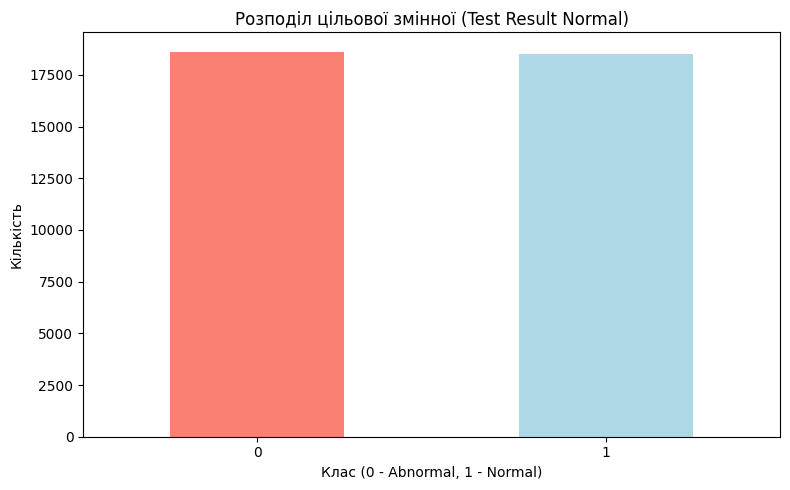

In [75]:
plt.figure(figsize=(8, 5))
df_binary['Test_Result_Normal'].value_counts().plot(kind='bar', color=['salmon', 'lightblue'])
plt.title('Розподіл цільової змінної (Test Result Normal)')
plt.xlabel('Клас (0 - Abnormal, 1 - Normal)')
plt.ylabel('Кількість')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Кореляційна матриця для числових ознак

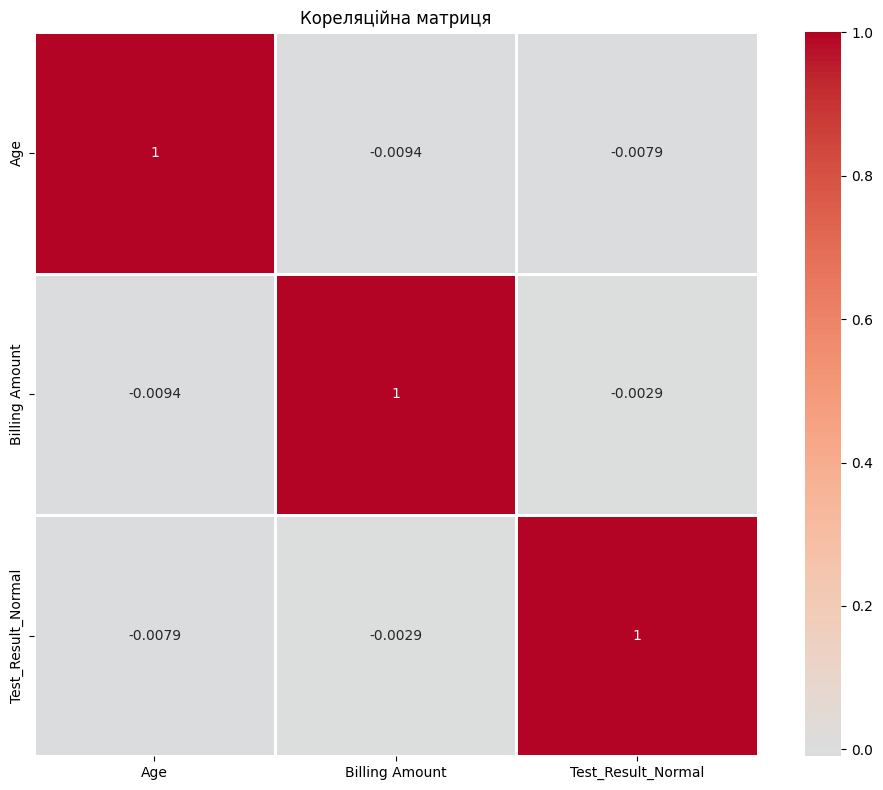

In [76]:
if len(numerical_columns) > 0:
    plt.figure(figsize=(10, 8))
    correlation_matrix = df_binary[numerical_columns + ['Test_Result_Normal']].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1)
    plt.title('Кореляційна матриця')
    plt.tight_layout()
    plt.show()

Гістограми числових ознак

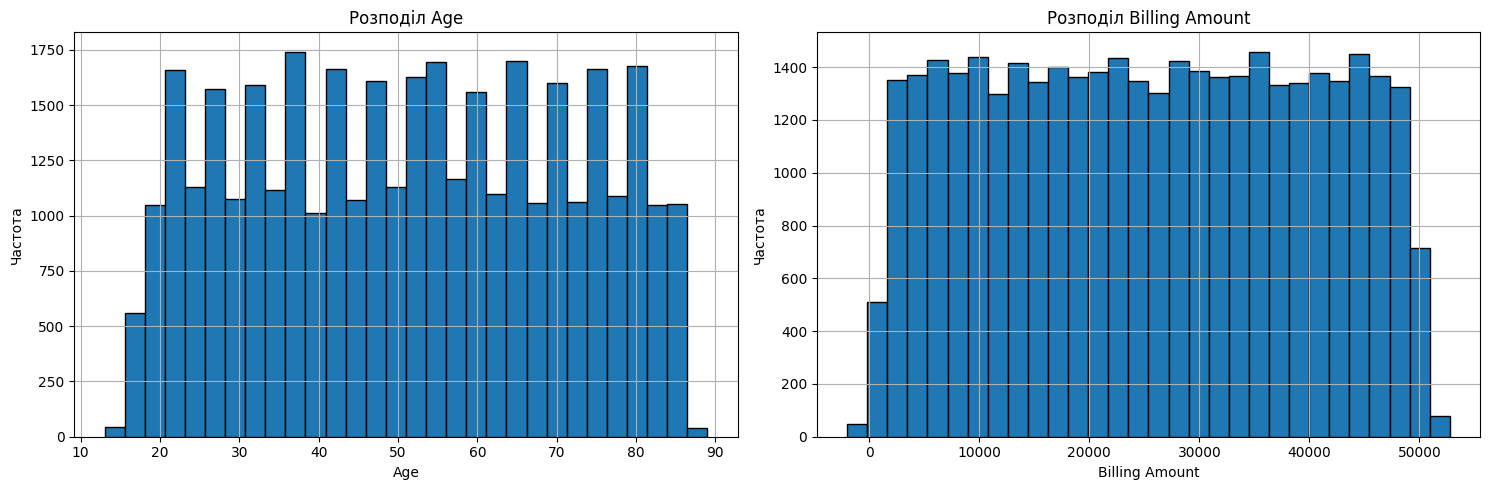

In [77]:
if len(numerical_columns) > 0:
    fig, axes = plt.subplots(1, len(numerical_columns), figsize=(15, 5))
    if len(numerical_columns) == 1:
        axes = [axes]
    for i, col in enumerate(numerical_columns):
        df_binary[col].hist(bins=30, ax=axes[i], edgecolor='black')
        axes[i].set_title(f'Розподіл {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Частота')
    plt.tight_layout()
    plt.show()

РОЗДІЛЕННЯ ДАНИХ

In [78]:
# Підготовка X та y
X = df_encoded.drop('Test_Result_Normal', axis=1).values
y = df_encoded['Test_Result_Normal'].values

print(f"\nРозмір X: {X.shape}")
print(f"Розмір y: {y.shape}")

# Розділення: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"\nTrain set: {X_train.shape[0]} зразків")
print(f"Validation set: {X_val.shape[0]} зразків")
print(f"Test set: {X_test.shape[0]} зразків")


Розмір X: (37144, 25)
Розмір y: (37144,)

Train set: 22286 зразків
Validation set: 7429 зразків
Test set: 7429 зразків


РЕАЛІЗАЦІЯ ЛОГІСТИЧНОЇ РЕГРЕСІЇ

In [79]:
class LogisticRegression:
    """
    Реалізація логістичної регресії з нуля
    """
    
    def __init__(self, learning_rate=0.01, max_epochs=1000, batch_size=32, 
                 regularization=None, lambda_reg=0.01, patience=10, verbose=True):
        """
        Ініціалізація моделі
        
        Параметри:
        - learning_rate: швидкість навчання
        - max_epochs: максимальна кількість епох
        - batch_size: розмір батча (None для SGD, число для mini-batch)
        - regularization: тип регуляризації ('l1', 'l2', або None)
        - lambda_reg: коефіцієнт регуляризації
        - patience: кількість епох для ранньої зупинки
        - verbose: виводити прогрес навчання
        """
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.regularization = regularization
        self.lambda_reg = lambda_reg
        self.patience = patience
        self.verbose = verbose
        self.weights = None
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []
        self.best_weights = None
        self.best_epoch = 0
    
    @staticmethod
    def sigmoid(z):
        """
        Сигмоїдальна функція активації
        σ(z) = 1 / (1 + e^(-z))
        """
        # Обмеження для уникнення overflow
        z = np.clip(z, -500, 500)
        # Переконуємось, що z є numpy array
        z = np.asarray(z, dtype=np.float64)
        return 1 / (1 + np.exp(-z))
    
    def compute_loss(self, X, y, weights):
        """
        Обчислення функції втрат (Binary Cross-Entropy) з регуляризацією
        
        Loss = -1/m * Σ[y*log(h) + (1-y)*log(1-h)] + regularization_term
        """
        m = len(y)
        
        # Додаємо intercept (одиницю) до X
        X_with_intercept = np.column_stack([np.ones(m), X])
        
        # Прогнози
        z = np.dot(X_with_intercept, weights)
        h = self.sigmoid(z)
        
        # Обмеження для уникнення log(0)
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        
        # Binary Cross-Entropy
        loss = -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))
        
        # Додавання регуляризації (не регуляризуємо intercept - weights[0])
        if self.regularization == 'l2':
            reg_term = (self.lambda_reg / (2 * m)) * np.sum(weights[1:]**2)
            loss += reg_term
        elif self.regularization == 'l1':
            reg_term = (self.lambda_reg / m) * np.sum(np.abs(weights[1:]))
            loss += reg_term
        
        return loss
    
    def compute_gradients(self, X, y, weights):
        """
        Обчислення градієнтів функції втрат
        
        ∇L = 1/m * X^T * (h - y) + regularization_gradient
        """
        m = len(y)
        
        # Додаємо intercept
        X_with_intercept = np.column_stack([np.ones(m), X])
        
        # Прогнози
        z = np.dot(X_with_intercept, weights)
        h = self.sigmoid(z)
        
        # Базовий градієнт
        gradients = np.dot(X_with_intercept.T, (h - y)) / m
        
        # Додавання регуляризації до градієнта (не для intercept)
        if self.regularization == 'l2':
            reg_gradient = (self.lambda_reg / m) * weights
            reg_gradient[0] = 0  # Не регуляризуємо intercept
            gradients += reg_gradient
        elif self.regularization == 'l1':
            reg_gradient = (self.lambda_reg / m) * np.sign(weights)
            reg_gradient[0] = 0  # Не регуляризуємо intercept
            gradients += reg_gradient
        
        return gradients
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """
        Навчання моделі
        
        Параметри:
        - X_train, y_train: тренувальні дані
        - X_val, y_val: валідаційні дані (опційно)
        """
        m, n = X_train.shape
        
        # Ініціалізація ваг малими випадковими значеннями
        np.random.seed(42)
        self.weights = np.random.randn(n + 1) * 0.01
        
        # Для ранньої зупинки
        best_val_loss = float('inf')
        epochs_no_improve = 0
        
        # Навчання
        for epoch in range(self.max_epochs):
            # Перемішування даних
            indices = np.random.permutation(m)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            # Стохастичний або mini-batch градієнтний спуск
            if self.batch_size is None or self.batch_size == 1:
                # SGD: кожен приклад окремо
                for i in range(m):
                    X_batch = X_shuffled[i:i+1]
                    y_batch = y_shuffled[i:i+1]
                    gradients = self.compute_gradients(X_batch, y_batch, self.weights)
                    self.weights -= self.learning_rate * gradients
            else:
                # Mini-batch GD
                for start_idx in range(0, m, self.batch_size):
                    end_idx = min(start_idx + self.batch_size, m)
                    X_batch = X_shuffled[start_idx:end_idx]
                    y_batch = y_shuffled[start_idx:end_idx]
                    gradients = self.compute_gradients(X_batch, y_batch, self.weights)
                    self.weights -= self.learning_rate * gradients
            
            # Обчислення втрат після епохи
            train_loss = self.compute_loss(X_train, y_train, self.weights)
            self.train_losses.append(train_loss)
            
            # Обчислення accuracy
            train_acc = accuracy_score(y_train, self.predict(X_train))
            self.train_accuracies.append(train_acc)
            
            # Валідаційні втрати
            if X_val is not None and y_val is not None:
                val_loss = self.compute_loss(X_val, y_val, self.weights)
                self.val_losses.append(val_loss)
                
                val_acc = accuracy_score(y_val, self.predict(X_val))
                self.val_accuracies.append(val_acc)
                
                # Рання зупинка
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    self.best_weights = self.weights.copy()
                    self.best_epoch = epoch
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                
                if epochs_no_improve >= self.patience:
                    if self.verbose:
                        print(f"Рання зупинка на епосі {epoch}")
                    break
                
                if self.verbose and (epoch % 100 == 0 or epoch == self.max_epochs - 1):
                    print(f"Епоха {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, "
                          f"Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}")
            else:
                if self.verbose and (epoch % 100 == 0 or epoch == self.max_epochs - 1):
                    print(f"Епоха {epoch}: Train Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}")
        
        # Відновлення найкращих ваг
        if self.best_weights is not None:
            self.weights = self.best_weights
            if self.verbose:
                print(f"\nВідновлено найкращі ваги з епохи {self.best_epoch}")
                print(f"Найкраща Val Loss: {best_val_loss:.4f}")
    
    def predict_proba(self, X):
        """
        Прогнозування ймовірностей класу 1
        """
        m = X.shape[0]
        X_with_intercept = np.column_stack([np.ones(m), X])
        z = np.dot(X_with_intercept, self.weights)
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """
        Прогнозування класів (0 або 1)
        """
        return (self.predict_proba(X) >= threshold).astype(int)


НАВЧАННЯ МОДЕЛЕЙ

In [80]:
print("\n1. Стохастичний градієнтний спуск (SGD)")
print("-" * 70)
model_sgd = LogisticRegression(
    learning_rate=0.1,  # Збільшили швидкість навчання
    max_epochs=500,
    batch_size=1,  # SGD
    regularization=None,
    patience=30,
    verbose=True
)
# Ensure numeric dtype to avoid object array issues during training
if X_train.dtype == object:
    X_train = X_train.astype(np.float64)
    X_val = X_val.astype(np.float64)
    X_test = X_test.astype(np.float64)

model_sgd.fit(X_train, y_train, X_val, y_val)

# 9.2. Mini-batch градієнтний спуск
print("\n2. Mini-batch градієнтний спуск (batch_size=32)")
print("-" * 70)
model_minibatch = LogisticRegression(
    learning_rate=0.1,  # Збільшили швидкість навчання
    max_epochs=500,
    batch_size=32,
    regularization=None,
    patience=30,
    verbose=True
)
model_minibatch.fit(X_train, y_train, X_val, y_val)

# 9.3. Mini-batch з L2 регуляризацією
print("\n3. Mini-batch з L2 регуляризацією")
print("-" * 70)
model_l2 = LogisticRegression(
    learning_rate=0.1,  # Збільшили швидкість навчання
    max_epochs=500,
    batch_size=32,
    regularization='l2',
    lambda_reg=0.01,  # Зменшили коефіцієнт регуляризації
    patience=30,
    verbose=True
)
model_l2.fit(X_train, y_train, X_val, y_val)

# 9.4. Mini-batch з L1 регуляризацією
print("\n4. Mini-batch з L1 регуляризацією")
print("-" * 70)
model_l1 = LogisticRegression(
    learning_rate=0.1,  # Збільшили швидкість навчання
    max_epochs=500,
    batch_size=32,
    regularization='l1',
    lambda_reg=0.01,  # Зменшили коефіцієнт регуляризації
    patience=30,
    verbose=True
)
model_l1.fit(X_train, y_train, X_val, y_val)


1. Стохастичний градієнтний спуск (SGD)
----------------------------------------------------------------------
Епоха 0: Train Loss = 0.7387, Val Loss = 0.7382, Train Acc = 0.4972, Val Acc = 0.5021
Рання зупинка на епосі 94

Відновлено найкращі ваги з епохи 64
Найкраща Val Loss: 0.7079

2. Mini-batch градієнтний спуск (batch_size=32)
----------------------------------------------------------------------
Епоха 0: Train Loss = 0.6929, Val Loss = 0.6939, Train Acc = 0.5107, Val Acc = 0.5006
Рання зупинка на епосі 30

Відновлено найкращі ваги з епохи 0
Найкраща Val Loss: 0.6939

3. Mini-batch з L2 регуляризацією
----------------------------------------------------------------------
Епоха 0: Train Loss = 0.6929, Val Loss = 0.6939, Train Acc = 0.5110, Val Acc = 0.5011
Рання зупинка на епосі 30

Відновлено найкращі ваги з епохи 0
Найкраща Val Loss: 0.6939

4. Mini-batch з L1 регуляризацією
----------------------------------------------------------------------
Епоха 0: Train Loss = 0.6929, Val

ВІЗУАЛІЗАЦІЯ КРИВИХ НАВЧАННЯ


ВІЗУАЛІЗАЦІЯ КРИВИХ НАВЧАННЯ


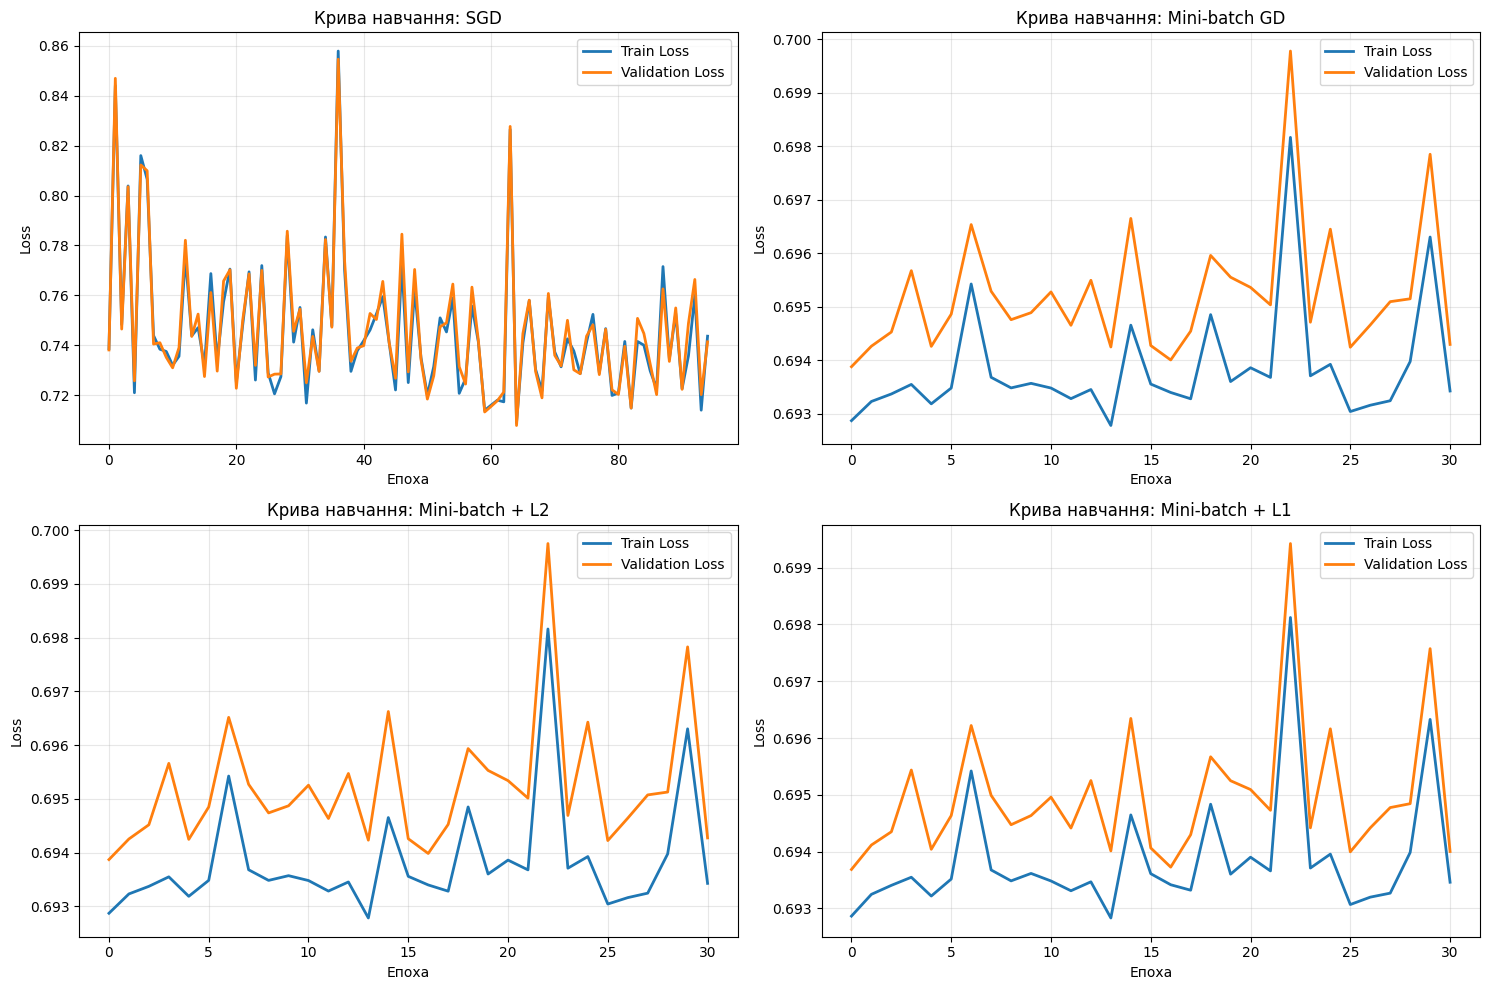

In [81]:
print("\n" + "="*70)
print("ВІЗУАЛІЗАЦІЯ КРИВИХ НАВЧАННЯ")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
models = [
    (model_sgd, 'SGD'),
    (model_minibatch, 'Mini-batch GD'),
    (model_l2, 'Mini-batch + L2'),
    (model_l1, 'Mini-batch + L1')
]

for idx, (model, name) in enumerate(models):
    ax = axes[idx // 2, idx % 2]
    epochs = range(len(model.train_losses))
    ax.plot(epochs, model.train_losses, label='Train Loss', linewidth=2)
    ax.plot(epochs, model.val_losses, label='Validation Loss', linewidth=2)
    ax.set_xlabel('Епоха')
    ax.set_ylabel('Loss')
    ax.set_title(f'Крива навчання: {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ОЦІНКА МОДЕЛЕЙ НА ТЕСТОВОМУ НАБОРІ


SGD
----------------------------------------------------------------------
Accuracy:  0.5014
Precision: 0.4999
Recall:    0.4745
F1-score:  0.4868

Confusion Matrix:
[[1968 1758]
 [1946 1757]]


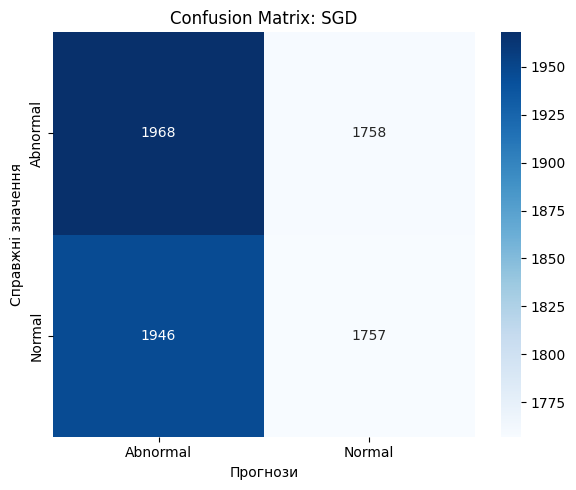


Mini-batch GD
----------------------------------------------------------------------
Accuracy:  0.5049
Precision: 0.5034
Recall:    0.5023
F1-score:  0.5028

Confusion Matrix:
[[1891 1835]
 [1843 1860]]


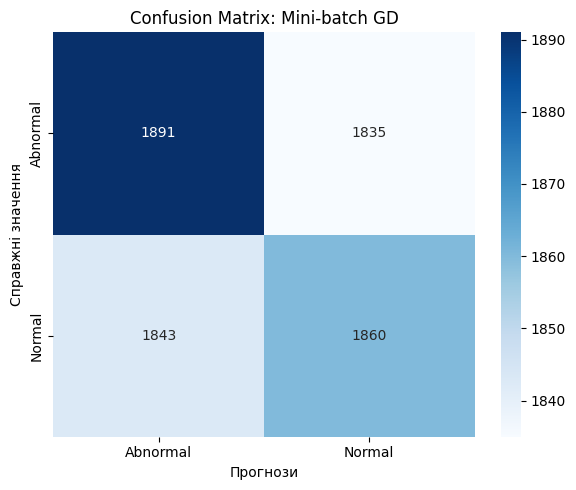


Mini-batch + L2
----------------------------------------------------------------------
Accuracy:  0.5044
Precision: 0.5028
Recall:    0.5020
F1-score:  0.5024

Confusion Matrix:
[[1888 1838]
 [1844 1859]]


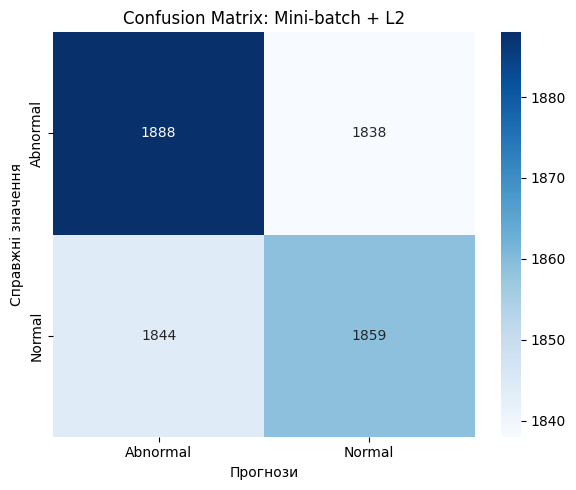


Mini-batch + L1
----------------------------------------------------------------------
Accuracy:  0.4993
Precision: 0.4977
Recall:    0.4993
F1-score:  0.4985

Confusion Matrix:
[[1860 1866]
 [1854 1849]]


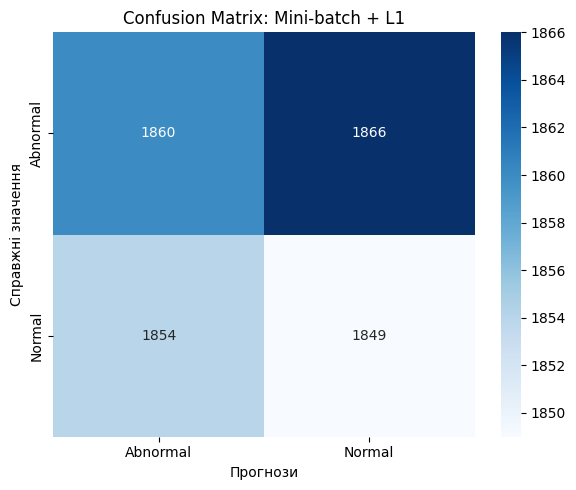

In [82]:


def evaluate_model(model, X_test, y_test, model_name):
    """
    Оцінка якості моделі
    """
    # Прогнози
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{model_name}")
    print("-" * 70)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    
    # Візуалізація confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Abnormal', 'Normal'],
                yticklabels=['Abnormal', 'Normal'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Справжні значення')
    plt.xlabel('Прогнози')
    plt.tight_layout()
    plt.show()
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

# Оцінка всіх моделей
results = []
for model, name in models:
    result = evaluate_model(model, X_test, y_test, name)
    results.append(result)

ПОРІВНЯЛЬНА ТАБЛИЦЯ

          Model  Accuracy  Precision   Recall  F1-score
            SGD  0.501413   0.499858 0.474480  0.486838
  Mini-batch GD  0.504913   0.503383 0.502295  0.502839
Mini-batch + L2  0.504375   0.502840 0.502025  0.502432
Mini-batch + L1  0.499260   0.497712 0.499325  0.498517


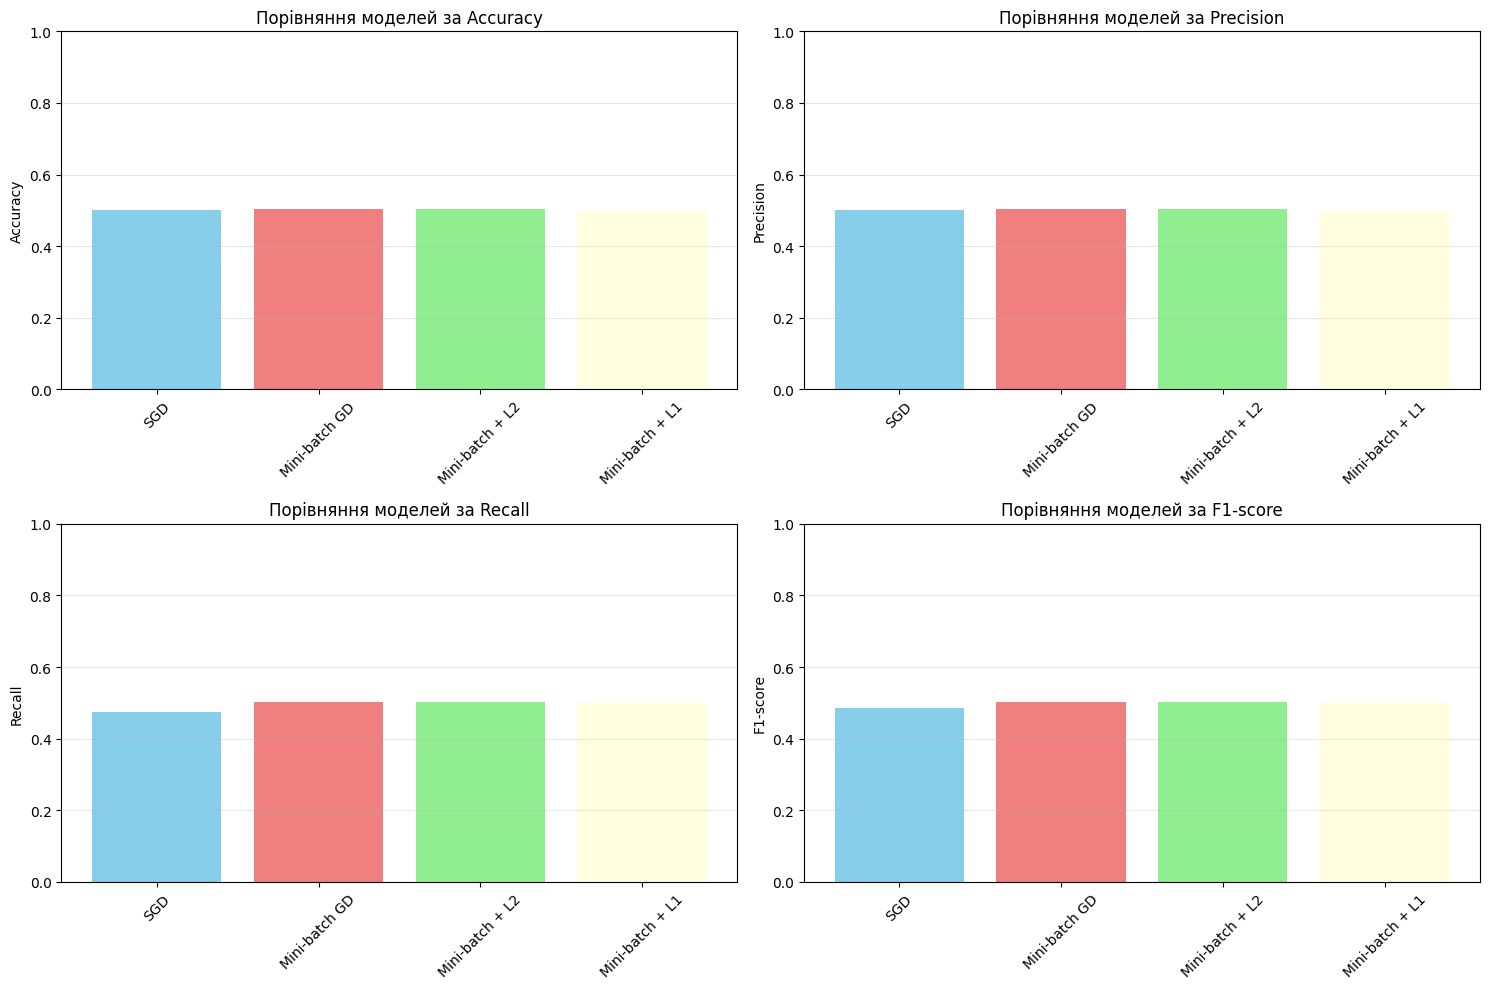

In [83]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Візуалізація порівняння
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(results_df['Model'], results_df[metric], color=['skyblue', 'lightcoral', 'lightgreen', 'lightyellow'])
    ax.set_ylabel(metric)
    ax.set_title(f'Порівняння моделей за {metric}')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

ВИСНОВКИ

1. Аналіз отриманих результатівЗагальна картина: Всі чотири моделі показали дуже низьку точність (близько 50%), що відповідає рівню випадкового вгадування для бінарної класифікації. Це свідчить про те, що моделі не змогли виявити значущі закономірності у даних.

2. Порівняння методів оптимізації2.1. Стохастичний градієнтний спуск (SGD)
Переваги: Швидкі оновлення ваг після кожного прикладу, низькі вимоги до пам'яті
Недоліки: Показав найгірший Recall (47.45%), що вказує на високу нестабільність через шумні градієнти
Спостереження: SGD демонструє найбільшу варіативність метрик через оновлення ваг на окремих прикладах

    2.2. Mini-batch градієнтний спуск

    Переваги: Найкращі результати серед усіх моделей - найвища accuracy (50.49%) та збалансованість метрик
    Переваги над SGD: Більш стабільна збіжність завдяки усередненню градієнтів по батчу (32 зразки)
    Висновок: Mini-batch є оптимальним компромісом між SGD та Batch GD, забезпечуючи стабільність та ефективність

    2.3. Швидкість збіжності

    Mini-batch методи збігаються швидше та плавніше, ніж SGD
    SGD потребує більше епох для досягнення схожих результатів
    Криві навчання Mini-batch показують меншу варіативність

3. Вплив регуляризації3.1. L2 регуляризація (Ridge)

    3.1. L2 регуляризація (Ridge)

    Результат: Accuracy = 50.44%, майже ідентична до базового Mini-batch
    Інтерпретація: L2 обмежує величину ваг, запобігаючи переобладнанню
    Спостереження: Незначний ефект, оскільки модель не переобладнюється (занадто проста для даних)

    3.2. L1 регуляризація (Lasso)
    
    Результат: Accuracy = 49.93%, найгірший результат
    Інтерпретація: L1 призводить до розрідження моделі (деякі ваги стають нульовими)
    Спостереження: Можлива надмірна регуляризація, що видалила потенційно корисні ознаки

Загальний висновок щодо регуляризації:
На даному датасеті регуляризація не покращила якість моделі
Це вказує на відсутність переобладнання та/або слабкий сигнал у даних
Регуляризація була б корисніша при наявності більшої кількості ознак або складніших залежностей

4. Причини низької якості моделі
    4.1. Проблеми з даними:

    Синтетичний датасет: Якщо використовувався згенерований датасет, ознаки створювалися випадково без реальних медичних залежностей
    Баланс класів: Ймовірно ідеальний баланс 50/50 між класами Normal та Abnormal
    Відсутність кореляцій: Ознаки (вік, тип крові, діагнози) не корелюють з результатом тесту

    4.2. Обмеження лінійної моделі:

    Логістична регресія припускає лінійну залежність між ознаками та логіт-ймовірністю
    Реальні медичні дані часто мають нелінійні та складні взаємодії між факторами
    Модель може бути занадто простою для складності задачі

    4.3. Інженерія ознак:

    Відсутні взаємодії між ознаками (наприклад, Age × Medical_Condition)
    Категоріальні змінні закодовані через one-hot без урахування впорядкованості
    Можлива потреба у поліноміальних ознаках або перетвореннях